# Phase 2a -- Comparaison Multi-LLMs sur GeoSQA
**GeoR2LLMs -- M2 IA, Universite Toulouse III Paul Sabatier**

## Objectif
Comparer les performances de 5 LLMs differents dans une configuration RAG
pour la question-reponse geographique sur le dataset GeoSQA.

| LLM | Famille | Taille | HuggingFace ID |
|-----|---------|--------|----------------|
| Qwen3-0.6B | Qwen | 0.6B | Qwen/Qwen3-0.6B |
| Qwen3-1.7B | Qwen | 1.7B | Qwen/Qwen3-1.7B |
| Llama-3.2-1B | Meta | 1.0B | meta-llama/Llama-3.2-1B-Instruct |
| Llama-3.2-3B | Meta | 3.0B | meta-llama/Llama-3.2-3B-Instruct |
| Ministral-3B | Mistral | 3.0B | mistralai/Ministral-3-3B-Instruct-2512 |

Retriever commun : BAAI/bge-m3 + FAISS | Corpus : Wikipedia FR | Dataset : GeoSQA

## Etape 1 -- Installation et Configuration

In [ ]:
# Installation de toutes les dependances necessaires
!pip install -q faiss-cpu sentence-transformers "transformers>=4.51.0" \
    accelerate datasets langchain-text-splitters \
    tqdm numpy pandas scikit-learn matplotlib seaborn \
    sentencepiece protobuf scipy
!pip install -q huggingface_hub

import torch
import random
import numpy as np
import os
import gc

# -- Verification GPU -----------------------------------------------------------
print("=" * 60)
print("CONFIGURATION MATERIELLE")
print("=" * 60)
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU detecte : {gpu_name}")
    print(f"Memoire GPU : {gpu_mem:.1f} Go")
    DEVICE = 'cuda'
else:
    print("Aucun GPU detecte -- execution sur CPU (sera lent)")
    DEVICE = 'cpu'

# -- Configuration globale -------------------------------------------------------
CONFIG = {
    'embedding_model': 'BAAI/bge-m3',
    'chunk_size': 512,
    'chunk_overlap': 50,
    'top_k': 5,
    'max_new_tokens': 100,
    'n_wiki_articles': 300,
    'dataset_name': 'rfr2003/Geo_Benchmark',
    'dataset_config': 'GeoSQA',
}

# -- Modeles a comparer -----------------------------------------------------------
MODELS = {
    'Qwen3-0.6B':  {'id': 'Qwen/Qwen3-0.6B',                        'family': 'Qwen',   'size_B': 0.6, 'type': 'qwen3'},
    'Qwen3-1.7B':  {'id': 'Qwen/Qwen3-1.7B',                        'family': 'Qwen',   'size_B': 1.7, 'type': 'qwen3'},
    'Llama-3.2-1B':{'id': 'meta-llama/Llama-3.2-1B-Instruct',        'family': 'Llama',  'size_B': 1.0, 'type': 'llama'},
    'Llama-3.2-3B':{'id': 'meta-llama/Llama-3.2-3B-Instruct',        'family': 'Llama',  'size_B': 3.0, 'type': 'llama'},
    'Ministral-3B':{'id': 'mistralai/Ministral-3-3B-Instruct-2512',   'family': 'Mistral','size_B': 3.0, 'type': 'mistral'},
}

# -- Reproductibilite -------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -- Dossier resultats ------------------------------------------------------------
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"\nConfiguration :")
for k, v in CONFIG.items():
    print(f"  {k:25s} : {v}")
print(f"  {'device':25s} : {DEVICE}")
print(f"  {'seed':25s} : {SEED}")
print(f"\nModeles a evaluer ({len(MODELS)}) :")
for name, info in MODELS.items():
    print(f"  {name:20s} | {info['family']:8s} | {info['size_B']:.1f}B | {info['id']}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 60.8 MB/s eta 0:00:00
CONFIGURATION MATERIELLE
GPU detecte : Tesla T4
Memoire GPU : 15.6 Go

Configuration :
  embedding_model           : BAAI/bge-m3
  chunk_size                : 512
  chunk_overlap             : 50
  top_k                     : 5
  max_new_tokens            : 100
  n_wiki_articles           : 300
  dataset_name              : rfr2003/Geo_Benchmark
  dataset_config            : GeoSQA
  device                    : cuda
  seed                      : 42

Modeles a evaluer (5) :
  Qwen3-0.6B           | Qwen     | 0.6B | Qwen/Qwen3-0.6B
  Qwen3-1.7B           | Qwen     | 1.7B | Qwen/Qwen3-1.7B
  Llama-3.2-1B         | Llama    | 1.0B | meta-llama/Llama-3.2-1B-Instruct
  Llama-3.2-3B         | Llama    | 3.0B | meta-llama/Llama-3.2-3B-Instruct
  Ministral-3B         | Mistral  | 3.0B | mistralai/Ministral-3-3B-Instruct-2512


## Etape 2 -- Modules partages

Trois modules principaux :
1. **RetrieverBGEM3** -- Indexation et recherche vectorielle (FAISS + BGE-m3)
2. **UnifiedGenerator** -- Generation de reponses (supporte Qwen3, Llama, Mistral)
3. **Evaluator** -- Metriques d'evaluation (generation + retrieval)

In [ ]:
import faiss
from sentence_transformers import SentenceTransformer
from langchain_text_splitters import RecursiveCharacterTextSplitter
from tqdm import tqdm
from typing import Optional


class RetrieverBGEM3:
    """Retriever base sur BAAI/bge-m3 et FAISS (IndexFlatIP avec normalisation L2)."""

    def __init__(self, model_name: Optional[str] = None, chunk_size: int = 512, chunk_overlap: int = 50):
        model_name = model_name or CONFIG['embedding_model']
        print(f"Chargement du modele d'embeddings : {model_name}")
        self.encoder = SentenceTransformer(model_name)
        self.dim: int = self.encoder.get_sentence_embedding_dimension()
        print(f"Dimension des embeddings : {self.dim}")

        self.splitter = RecursiveCharacterTextSplitter(
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap,
            separators=['\n\n', '\n', '. ', ' ', '']
        )

        self.index: Optional[faiss.IndexFlatIP] = None
        self.chunks: list[str] = []
        self.chunk_metas: list[dict] = []

    def index_documents(self, documents: list[str], metadatas: Optional[list[dict]] = None):
        """Decoupe les documents en chunks, encode et indexe dans FAISS."""
        print(f"Indexation de {len(documents)} documents...")
        if metadatas is None:
            metadatas = [{}] * len(documents)

        self.chunks = []
        self.chunk_metas = []
        for doc_text, meta in zip(documents, metadatas):
            splits = self.splitter.split_text(doc_text)
            for chunk_text in splits:
                self.chunks.append(chunk_text)
                self.chunk_metas.append(meta)

        print(f"  {len(self.chunks)} chunks crees")

        print("  Encodage des chunks...")
        embeddings = self.encoder.encode(
            self.chunks,
            show_progress_bar=True,
            batch_size=64,
            normalize_embeddings=True
        )
        embeddings = np.array(embeddings, dtype='float32')

        self.index = faiss.IndexFlatIP(self.dim)
        self.index.add(embeddings)  # type: ignore[call-arg]
        print(f"  Index FAISS cree : {self.index.ntotal} vecteurs")

    def retrieve(self, query: str, top_k: int = 5, return_scores: bool = False) -> list[dict]:
        """Recherche les top_k chunks les plus pertinents pour la requete."""
        if self.index is None:
            raise ValueError("L'index n'a pas encore ete construit. Appelez index_documents() d'abord.")

        q_emb = self.encoder.encode(
            [query],
            normalize_embeddings=True
        ).astype('float32')

        scores, indices = self.index.search(q_emb, top_k)  # type: ignore[call-arg]

        results = []
        for rank, (score, idx) in enumerate(zip(scores[0], indices[0])):
            if idx < 0:
                continue
            result = {
                'text': self.chunks[idx],
                'metadata': self.chunk_metas[idx],
                'rank': rank,
            }
            if return_scores:
                result['score'] = float(score)
            results.append(result)

        return results


print("Classe RetrieverBGEM3 definie.")

Classe RetrieverBGEM3 definie.


In [ ]:
import string
from collections import Counter


class Evaluator:
    """Metriques d'evaluation pour la generation et le retrieval."""

    @staticmethod
    def normalize(text: str) -> str:
        """Normalise un texte : minuscules, suppression ponctuation/articles."""
        text = text.lower().strip()
        text = text.translate(str.maketrans('', '', string.punctuation))
        stop_words = {'le', 'la', 'les', 'l', 'un', 'une', 'des', 'du', 'de',
                      'the', 'a', 'an', 'is', 'are', 'was', 'were'}
        tokens = text.split()
        tokens = [t for t in tokens if t not in stop_words]
        return ' '.join(tokens)

    @staticmethod
    def exact_match(pred: str, truth: str) -> float:
        """1.0 si les textes normalises sont identiques, sinon 0.0."""
        pred_n = Evaluator.normalize(pred)
        truth_n = Evaluator.normalize(truth)
        if pred_n == truth_n:
            return 1.0
        if truth_n in pred_n and len(pred_n) < len(truth_n) * 2:
            return 1.0
        return 0.0

    @staticmethod
    def f1(pred: str, truth: str) -> float:
        """F1 au niveau des tokens entre la prediction et la verite."""
        pred_tokens = Evaluator.normalize(pred).split()
        truth_tokens = Evaluator.normalize(truth).split()
        if not pred_tokens or not truth_tokens:
            return 0.0
        common = Counter(pred_tokens) & Counter(truth_tokens)
        n_common = sum(common.values())
        if n_common == 0:
            return 0.0
        precision = n_common / len(pred_tokens)
        recall = n_common / len(truth_tokens)
        return 2 * precision * recall / (precision + recall)

    @staticmethod
    def contains(pred: str, truth: str) -> float:
        """1.0 si la prediction contient les mots-cles de la verite."""
        pred_n = Evaluator.normalize(pred)
        truth_n = Evaluator.normalize(truth)
        truth_tokens = truth_n.split()
        if not truth_tokens:
            return 0.0
        found = sum(1 for t in truth_tokens if t in pred_n)
        return 1.0 if found >= len(truth_tokens) / 2 else 0.0

    @staticmethod
    def accuracy_mcq(pred_letter: str, true_letter: str) -> float:
        """1.0 si les lettres correspondent, sinon 0.0."""
        return 1.0 if pred_letter.strip().upper() == true_letter.strip().upper() else 0.0

    @staticmethod
    def evaluate_batch(preds: list, truths: list) -> dict:
        """Calcule toutes les metriques de generation sur un lot."""
        n = len(preds)
        em_scores = [Evaluator.exact_match(p, t) for p, t in zip(preds, truths)]
        f1_scores = [Evaluator.f1(p, t) for p, t in zip(preds, truths)]
        contains_scores = [Evaluator.contains(p, t) for p, t in zip(preds, truths)]
        return {
            'exact_match': np.mean(em_scores),
            'f1': np.mean(f1_scores),
            'contains': np.mean(contains_scores),
            'em_scores': em_scores,
            'f1_scores': f1_scores,
            'contains_scores': contains_scores,
        }

    @staticmethod
    def hit_rate_at_k(retrieved_docs: list, answer_text: str, k: int) -> float:
        """1.0 si la reponse apparait dans les top-k documents recuperes."""
        answer_norm = Evaluator.normalize(answer_text)
        answer_tokens = answer_norm.split()
        if not answer_tokens:
            return 0.0
        for doc in retrieved_docs[:k]:
            doc_norm = Evaluator.normalize(doc.get('text', ''))
            found = sum(1 for t in answer_tokens if t in doc_norm)
            if found >= max(1, len(answer_tokens) // 2):
                return 1.0
        return 0.0

    @staticmethod
    def mrr_at_k(retrieved_docs: list, answer_text: str, k: int) -> float:
        """Mean Reciprocal Rank : 1/rang du premier document pertinent."""
        answer_norm = Evaluator.normalize(answer_text)
        answer_tokens = answer_norm.split()
        if not answer_tokens:
            return 0.0
        for i, doc in enumerate(retrieved_docs[:k]):
            doc_norm = Evaluator.normalize(doc.get('text', ''))
            found = sum(1 for t in answer_tokens if t in doc_norm)
            if found >= max(1, len(answer_tokens) // 2):
                return 1.0 / (i + 1)
        return 0.0

    @staticmethod
    def error_examples(preds, truths, questions, n=5):
        """Retourne les n pires exemples (plus faible F1)."""
        scores = [(i, Evaluator.f1(p, t)) for i, (p, t) in enumerate(zip(preds, truths))]
        scores.sort(key=lambda x: x[1])
        examples = []
        for idx, f1_score in scores[:n]:
            examples.append({
                'index': idx,
                'question': questions[idx],
                'prediction': preds[idx],
                'truth': truths[idx],
                'f1': f1_score
            })
        return examples

    @staticmethod
    def success_examples(preds, truths, questions, n=5):
        """Retourne les n meilleurs exemples (plus haut F1)."""
        scores = [(i, Evaluator.f1(p, t)) for i, (p, t) in enumerate(zip(preds, truths))]
        scores.sort(key=lambda x: x[1], reverse=True)
        examples = []
        for idx, f1_score in scores[:n]:
            examples.append({
                'index': idx,
                'question': questions[idx],
                'prediction': preds[idx],
                'truth': truths[idx],
                'f1': f1_score
            })
        return examples


print("Classe Evaluator definie.")

Classe Evaluator definie.


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import re
from typing import Optional


# -- Prompts -------------------------------------------------------------------
SYSTEM_PROMPT = "Tu es un assistant specialise en geographie. Reponds de maniere concise et precise."

MCQ_PROMPT_TEMPLATE = """Question a choix multiples en geographie.
{context_block}
Question : {question}

Choix :
A) {A}
B) {B}
C) {C}
D) {D}

Reponds UNIQUEMENT par la lettre de la bonne reponse (A, B, C ou D).
Reponse :"""


def extract_answer_letter(text: str) -> str:
    """Extrait la lettre de reponse (A/B/C/D) d'un texte genere."""
    text = text.strip()
    if text and text[0].upper() in 'ABCD':
        return text[0].upper()
    match = re.search(r'\b([ABCD])\s*[\)\.]', text)
    if match:
        return match.group(1).upper()
    match = re.search(r'\b([ABCD])\b', text)
    if match:
        return match.group(1).upper()
    return text[:1].upper() if text else 'X'


# -- Parametres de generation par famille de modele ----------------------------
GENERATION_PARAMS = {
    'qwen3':  {'temperature': 0.7, 'top_p': 0.8, 'top_k': 20, 'do_sample': True},
    'llama':  {'temperature': 0.6, 'top_p': 0.9, 'do_sample': True},
    'mistral':{'temperature': 0.7, 'top_p': 0.9, 'do_sample': True},
}


class UnifiedGenerator:
    """Generateur unifie supportant Qwen3, Llama, et Mistral."""

    def __init__(self, model_id: str, model_type: str = 'auto'):
        self.model_id = model_id
        self.model_type = model_type

        # Auto-detection du type de modele
        if model_type == 'auto':
            model_id_lower = model_id.lower()
            if 'qwen' in model_id_lower:
                self.model_type = 'qwen3'
            elif 'llama' in model_id_lower:
                self.model_type = 'llama'
            elif 'mistral' in model_id_lower or 'ministral' in model_id_lower:
                self.model_type = 'mistral'
            else:
                self.model_type = 'qwen3'  # defaut

        self.gen_params = GENERATION_PARAMS.get(self.model_type, GENERATION_PARAMS['qwen3'])

        print(f"Chargement du modele : {model_id} (type={self.model_type})")

        # Chargement avec gestion speciale pour Llama (licence Meta)
        actual_id = model_id
        if self.model_type == 'llama':
            try:
                print(f"  Tentative de chargement depuis {model_id}...")
                self.tokenizer = AutoTokenizer.from_pretrained(model_id)
                self.model = AutoModelForCausalLM.from_pretrained(
                    model_id,
                    torch_dtype="auto",
                    device_map="auto"
                )
                actual_id = model_id
            except Exception as e:
                print(f"  Echec ({e})")
                alt_id = model_id.replace('meta-llama/', 'unsloth/')
                print(f"  Fallback vers le miroir : {alt_id}")
                self.tokenizer = AutoTokenizer.from_pretrained(alt_id)
                self.model = AutoModelForCausalLM.from_pretrained(
                    alt_id,
                    torch_dtype="auto",
                    device_map="auto"
                )
                actual_id = alt_id
        else:
            self.tokenizer = AutoTokenizer.from_pretrained(model_id)
            self.model = AutoModelForCausalLM.from_pretrained(
                model_id,
                torch_dtype="auto",
                device_map="auto"
            )

        self.model.eval()
        self.actual_id = actual_id
        print(f"  Modele charge sur : {self.model.device}")
        print(f"  Parametres de generation : {self.gen_params}")

    def generate(self, prompt: str, max_new_tokens: Optional[int] = None) -> str:
        """Genere une reponse a partir d'un prompt utilisateur."""
        max_new_tokens = max_new_tokens or CONFIG['max_new_tokens']

        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": prompt}
        ]

        # Formatage avec le template de chat
        if self.model_type == 'qwen3':
            text = self.tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True,
                enable_thinking=False
            )
        else:
            text = self.tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True
            )

        inputs = self.tokenizer(text, return_tensors='pt').to(self.model.device)

        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                pad_token_id=self.tokenizer.eos_token_id,
                **self.gen_params
            )

        generated_ids = outputs[0][inputs['input_ids'].shape[1]:]
        response = self.tokenizer.decode(generated_ids, skip_special_tokens=True)
        return response.strip()

    def generate_mcq(self, question: str, choices: dict, context: Optional[str] = None) -> str:
        """Genere une prediction pour une question a choix multiples."""
        context_block = ""
        if context:
            context_block = f"Contexte :\n{context}\n"

        prompt = MCQ_PROMPT_TEMPLATE.format(
            context_block=context_block,
            question=question,
            A=choices.get('A', ''),
            B=choices.get('B', ''),
            C=choices.get('C', ''),
            D=choices.get('D', '')
        )

        raw_response = self.generate(prompt, max_new_tokens=30)
        letter = extract_answer_letter(raw_response)
        return letter

    def free_memory(self):
        """Libere la memoire GPU occupee par le modele."""
        print(f"  Liberation de la memoire pour {self.model_id}...")
        del self.model
        del self.tokenizer
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            mem_free = torch.cuda.mem_get_info()[0] / 1e9
            mem_total = torch.cuda.mem_get_info()[1] / 1e9
            print(f"  Memoire GPU : {mem_free:.1f} / {mem_total:.1f} Go disponible")


print("Classe UnifiedGenerator definie.")

Classe UnifiedGenerator definie.


## Etape 3 -- Chargement des donnees

- **Dataset** : GeoSQA (questions geographiques a choix multiples)
- **Corpus** : Wikipedia francais (articles filtres par mots-cles geographiques)

Le retriever et l'index FAISS sont construits **une seule fois** et reutilises pour tous les modeles.

In [ ]:
from datasets import load_dataset, Dataset
import re as re_module, re

# == Chargement du dataset GeoSQA / GKMC ======================================
print(f"Chargement du dataset {CONFIG['dataset_config']}...")
ds_raw = load_dataset(CONFIG['dataset_name'], CONFIG['dataset_config'], split='test')
ds = ds_raw

print(f"Dataset charge : {len(ds)} questions")

questions      = ds['question']
scenarios      = ds['scenario'] if 'scenario' in ds.column_names else [None]*len(ds)
correct_letters = ds['answer']
choices        = [{'A': r['A'], 'B': r['B'], 'C': r['C'], 'D': r['D']} for r in ds]
correct_texts  = [r[r['answer']] for r in ds]

MAX_QUESTIONS = min(200, len(ds))
print(f"Evaluation sur {MAX_QUESTIONS} questions")

from collections import Counter
letter_dist = Counter(correct_letters[:MAX_QUESTIONS])
print("Distribution des reponses correctes :")
for letter in sorted(letter_dist.keys()):
    print(f"  {letter} : {letter_dist[letter]} ({letter_dist[letter]/MAX_QUESTIONS*100:.1f}%)")

# == Mots-cles geographiques ==================================================
GEO_KEYWORDS_FR = [
    'geographie','continent','europe','afrique','asie','amerique',
    'antarctique','oceanie','capitale','departement','prefecture',
    'province','territoire','fleuve','riviere','montagne','volcan',
    'relief','plaine','plateau','colline','vallee','archipel',
    'peninsule','littoral','climat','latitude','longitude','altitude',
    'tropique','equateur','hemisphere','atlantique','pacifique',
    'mediterranee','superficie','frontiere','habitants','densite',
    'alpes','pyrenees','himalaya','sahara',
    'paris','lyon','marseille','toulouse','bordeaux',
    'londres','berlin','pekin','tokyo',
]

GEO_KEYWORDS_EN = [
    'geography','continent','europe','africa','asia','america',
    'antarctica','oceania','capital','department','prefecture',
    'province','territory','river','mountain','volcano',
    'plain','plateau','valley','archipelago','peninsula','coast',
    'climate','latitude','longitude','altitude','tropical',
    'equator','hemisphere','atlantic','pacific','mediterranean',
    'area','border','population','density',
    'alps','pyrenees','himalayas','sahara',
    'paris','london','berlin','beijing','tokyo',
    'country','countries','city','cities','located',
    'ocean','sea','lake','island','desert','forest',
]

GEO_TITLE_FR = ['departement','region','commune','canton','province',
                'pays','ville','ile','lac','mer','ocean','fleuve',
                'riviere','montagne','geographie','district']

GEO_TITLE_EN = ['department','region','province','country','city','island',
                'lake','sea','ocean','river','mountain','geography','district',
                'geography of','list of']

BIOGRAPHY_PATTERNS = [
    re.compile(r'^.{2,50},?\s+n[ee]+\s+(le\s+|en\s+)', re.IGNORECASE),
    re.compile(r'^.{2,50}\s+est\s+un(e)?\s+', re.IGNORECASE),
    re.compile(r'^.{2,50}\s+\(\d{1,2}\s+\w+\s+\d{4}\s*[-]', re.IGNORECASE),
    re.compile(r'^.{2,50}\s+\(\d{4}\s*[-]', re.IGNORECASE),
    re.compile(r'^.{2,50}\s+was born', re.IGNORECASE),
    re.compile(r'^.{2,50}\s+is an?\s+(American|British|French|Chinese)', re.IGNORECASE),
    re.compile(r'^.{2,50}\s+\(born\s+\d', re.IGNORECASE),
]

def load_wiki_corpus(lang='fr', n_articles=300, max_scan=50000, seed=42):
    """Charge un corpus Wikipedia geographique dans la langue specifiee (fr ou en)."""
    wiki_config   = f'20231101.{lang}'
    keywords      = GEO_KEYWORDS_FR    if lang == 'fr' else GEO_KEYWORDS_EN
    title_marks   = GEO_TITLE_FR       if lang == 'fr' else GEO_TITLE_EN
    geo_pats      = [re.compile(r'\b' + re.escape(kw) + r'\b') for kw in keywords]
    title_pats    = [re.compile(r'\b' + re.escape(kw) + r'\b') for kw in title_marks]

    print(f"\nChargement Wikipedia {lang.upper()} (streaming, seed={seed})...")
    stream = load_dataset('wikimedia/wikipedia', wiki_config,
                          split='train', streaming=True
                          ).shuffle(seed=seed, buffer_size=10000)
    docs = []
    scanned = n_bio = 0

    for article in tqdm(stream, total=max_scan, desc=f'Wikipedia {lang.upper()}'):
        scanned += 1
        if scanned > max_scan: break
        text  = article.get('text', '')
        title = article.get('title', '')
        if any(p.search(text[:200]) for p in BIOGRAPHY_PATTERNS):
            n_bio += 1; continue
        title_lower = title.lower()
        text_lower  = (title + ' ' + text[:2000]).lower()
        title_is_geo = any(p.search(title_lower) for p in title_pats)
        n_matches    = sum(1 for p in geo_pats if p.search(text_lower))
        if n_matches >= (2 if title_is_geo else 3):
            docs.append({'title': title, 'text': text[:3000],
                         'metadata': {'source': f'wikipedia_{lang}',
                                      'title': title, 'lang': lang}})
        if len(docs) >= n_articles: break

    print(f"  {len(docs)} articles retenus ({scanned} scannes, {n_bio} biographies exclues)")
    return docs

# == Chargement des deux corpus ================================================
print("=" * 60)
print("CHARGEMENT DES CORPUS : Wikipedia FR et Wikipedia EN")
print("Objectif : valider que le mismatch FR/EN est la cause du")
print("mauvais retrieval, et non un probleme inherent a BGE-m3.")
print("=" * 60)

wiki_docs_fr = load_wiki_corpus(lang='fr', n_articles=CONFIG['n_wiki_articles'])
wiki_docs_en = load_wiki_corpus(lang='en', n_articles=CONFIG['n_wiki_articles'])

# == Construction des deux index FAISS =========================================
print("\n" + "=" * 60)
print("CONSTRUCTION DES INDEX FAISS (FR et EN, meme retriever BGE-m3)")
print("=" * 60)

retriever_fr = RetrieverBGEM3(model_name=CONFIG['embedding_model'],
                              chunk_size=CONFIG['chunk_size'],
                              chunk_overlap=CONFIG['chunk_overlap'])
retriever_fr.index_documents([d['text'] for d in wiki_docs_fr],
                             [d['metadata'] for d in wiki_docs_fr])
print("Index FAISS FR construit.")

retriever_en = RetrieverBGEM3(model_name=CONFIG['embedding_model'],
                              chunk_size=CONFIG['chunk_size'],
                              chunk_overlap=CONFIG['chunk_overlap'])
retriever_en.index_documents([d['text'] for d in wiki_docs_en],
                             [d['metadata'] for d in wiki_docs_en])
print("Index FAISS EN construit.")

# == Test comparatif des deux retrievers =======================================
print("\n" + "=" * 60)
print("TEST COMPARATIF RETRIEVER FR vs EN (question exemple)")
print("=" * 60)
test_q = str(questions[0])
print(f"Question : {test_q[:200]}")
for label, retr in [("FR", retriever_fr), ("EN", retriever_en)]:
    print(f"\n--- Retriever {label} ---")
    results = retr.retrieve(test_q, top_k=3, return_scores=True)
    for i, res in enumerate(results):
        title = res['metadata'].get('title', 'N/A')
        score = res.get('score', 0)
        print(f"  [{i+1}] Score={score:.4f} | {title}")
        print(f"       {res['text'][:100].replace(chr(10),' ')}...")


Chargement du dataset GeoSQA...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

GeoSQA/train-00000-of-00001.parquet:   0%|          | 0.00/836k [00:00<?, ?B/s]

GeoSQA/validation-00000-of-00001.parquet:   0%|          | 0.00/211k [00:00<?, ?B/s]

...

  Index FAISS cree : 2143 vecteurs
Index FAISS FR construit.
Chargement du modele d'embeddings : BAAI/bge-m3


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Dimension des embeddings : 1024
Indexation de 300 documents...
  1547 chunks crees
  Encodage des chunks...


Batches:   0%|          | 0/25 [00:00<?, ?it/s]

  Index FAISS cree : 1547 vecteurs
Index FAISS EN construit.

TEST COMPARATIF RETRIEVER FR vs EN (question exemple)
Question : While the Tiangong-1 and Shenzhou-9 combination is in orbit, the celestial system it forms with the celestial body it orbits is of the same level as which of the following? (　　)

--- Retriever FR ---
  [1] Score=0.4157 | Politique climatique
       . (ce travail ne tient toutefois pas compte des émissions des transports aériens et maritimes intern...
  [2] Score=0.3966 | Observatoire du Cerro Armazones
       Un télescope de  fabriqué par Meade Instruments, qui appartient à l'UCN. Il a été démonté entretemps...
  [3] Score=0.3863 | Enclave de haute mer dans la mer d'Okhotsk
       L'enclave de haute mer dans la mer d'Okhotsk, surnommée  en anglais en raison de sa forme de cacahou...

--- Retriever EN ---
  [1] Score=0.4094 | Monument to Columbus (Valladolid)
       Above, the Earth globe, made of white stone from the quarries of Ibeas, is circumvented by a bron

## Etape 4 -- Evaluation de chaque LLM

Pour chaque modele :
1. **Chargement** du modele et du tokenizer
2. **Evaluation Baseline** (LLM seul, sans contexte RAG)
3. **Evaluation RAG** (LLM + contexte Wikipedia)
4. **Liberation de la memoire GPU** (critique pour eviter les erreurs OOM)

Le retriever est reutilise tel quel pour tous les modeles.

In [ ]:
import time

# == Fonctions utilitaires locales =============================================

def compute_accuracy(pred_letters, true_letters):
    """Calcule l'accuracy MCQ."""
    n = len(pred_letters)
    correct = sum(1 for p, t in zip(pred_letters, true_letters)
                  if p.strip().upper() == t.strip().upper())
    return correct / n if n > 0 else 0.0

def compute_f1_mean(pred_letters, true_texts):
    """Calcule le F1 moyen entre les lettres predites et les textes corrects."""
    scores = [Evaluator.f1(p, t) for p, t in zip(pred_letters, true_texts)]
    return sum(scores) / len(scores) if scores else 0.0

def compute_retrieval_metrics(retriever, questions_list, correct_texts_list, top_k=5):
    """Calcule HR@5 et MRR@5 pour un retriever donne."""
    hr_list, mrr_list = [], []
    for i in range(len(questions_list)):
        docs = retriever.retrieve(questions_list[i], top_k=top_k)
        hr_list.append(Evaluator.hit_rate_at_k(docs, correct_texts_list[i], k=top_k))
        mrr_list.append(Evaluator.mrr_at_k(docs, correct_texts_list[i], k=top_k))
    return {
        'hit_rate_5': sum(hr_list)  / len(hr_list)  if hr_list  else 0.0,
        'mrr_5':      sum(mrr_list) / len(mrr_list) if mrr_list else 0.0,
    }

def build_prompt(question, scenario, choices_dict, context_docs):
    """Construit le prompt MCQ avec ou sans contexte RAG."""
    if context_docs:
        ctx_texts   = [d['text'] for d in context_docs]
        ctx_joined  = "\n---\n".join(ctx_texts[:CONFIG['top_k']])
        context_block = f"Contexte :\n{ctx_joined}\n\n"
    else:
        context_block = ""
    return MCQ_PROMPT_TEMPLATE.format(
        context_block=context_block,
        question=question,
        A=choices_dict.get('A', ''),
        B=choices_dict.get('B', ''),
        C=choices_dict.get('C', ''),
        D=choices_dict.get('D', ''),
    )

# == Calcul des metriques de retrieval (une seule fois, independant du LLM) ====
print("Calcul des metriques de retrieval (HR@5, MRR@5)...")
retrieval_metrics_fr = compute_retrieval_metrics(
    retriever_fr, questions[:MAX_QUESTIONS], correct_texts[:MAX_QUESTIONS])
retrieval_metrics_en = compute_retrieval_metrics(
    retriever_en, questions[:MAX_QUESTIONS], correct_texts[:MAX_QUESTIONS])

print(f"  Retriever FR : HR@5={retrieval_metrics_fr['hit_rate_5']:.4f}, "
      f"MRR@5={retrieval_metrics_fr['mrr_5']:.4f}")
print(f"  Retriever EN : HR@5={retrieval_metrics_en['hit_rate_5']:.4f}, "
      f"MRR@5={retrieval_metrics_en['mrr_5']:.4f}")

if retrieval_metrics_en['hit_rate_5'] > retrieval_metrics_fr['hit_rate_5']:
    print("  --> Corpus EN : meilleur retrieval que FR (mismatch confirme)")
else:
    print("  --> Corpus FR et EN : retrieval similaire")

# == Boucle principale d'evaluation ============================================
all_results = {}
correct_texts_eval = [correct_texts[i] for i in range(MAX_QUESTIONS)]

for model_name, model_info in MODELS.items():
    print(f"\n{'='*70}")
    print(f"EVALUATION : {model_name} ({model_info['id']})")
    print(f"{'='*70}")

    try:
        gen = UnifiedGenerator(model_info['id'], model_type=model_info['type'])
    except Exception as e:
        print(f"ERREUR chargement {model_name}: {e}")
        all_results[model_name] = {'error': str(e)}
        continue

    # ---- Baseline (sans RAG) ------------------------------------------------
    print(f"\n--- {model_name} : Baseline ---")
    base_letters = []
    t0 = time.time()
    for i in tqdm(range(MAX_QUESTIONS), desc=f'{model_name} Baseline'):
        scen   = scenarios[i] if scenarios[i] else ""
        prompt = build_prompt(questions[i], scen, choices[i], [])
        raw    = gen.generate(prompt)
        base_letters.append(extract_answer_letter(raw))
    t_base = time.time() - t0

    base_acc = compute_accuracy(base_letters, correct_letters[:MAX_QUESTIONS])
    base_f1  = compute_f1_mean(base_letters, correct_texts_eval)
    base_metrics = {'accuracy': base_acc, 'f1': base_f1,
                    'exact_match': 0.0, 'time_s': t_base}

    # ---- RAG-FR (corpus Wikipedia francais) ---------------------------------
    print(f"\n--- {model_name} : RAG-FR (Wikipedia FR) ---")
    fr_letters = []
    t0 = time.time()
    for i in tqdm(range(MAX_QUESTIONS), desc=f'{model_name} RAG-FR'):
        scen   = scenarios[i] if scenarios[i] else ""
        docs   = retriever_fr.retrieve(questions[i] + " " + scen,
                                       top_k=CONFIG['top_k'])
        prompt = build_prompt(questions[i], scen, choices[i], docs)
        raw    = gen.generate(prompt)
        fr_letters.append(extract_answer_letter(raw))
    t_fr = time.time() - t0

    fr_acc = compute_accuracy(fr_letters, correct_letters[:MAX_QUESTIONS])
    fr_f1  = compute_f1_mean(fr_letters, correct_texts_eval)
    fr_metrics = {'accuracy': fr_acc, 'f1': fr_f1,
                  'exact_match': 0.0, 'time_s': t_fr}

    # ---- RAG-EN (corpus Wikipedia anglais) ----------------------------------
    print(f"\n--- {model_name} : RAG-EN (Wikipedia EN) ---")
    en_letters = []
    t0 = time.time()
    for i in tqdm(range(MAX_QUESTIONS), desc=f'{model_name} RAG-EN'):
        scen   = scenarios[i] if scenarios[i] else ""
        docs   = retriever_en.retrieve(questions[i] + " " + scen,
                                       top_k=CONFIG['top_k'])
        prompt = build_prompt(questions[i], scen, choices[i], docs)
        raw    = gen.generate(prompt)
        en_letters.append(extract_answer_letter(raw))
    t_en = time.time() - t0

    en_acc = compute_accuracy(en_letters, correct_letters[:MAX_QUESTIONS])
    en_f1  = compute_f1_mean(en_letters, correct_texts_eval)
    en_metrics = {'accuracy': en_acc, 'f1': en_f1,
                  'exact_match': 0.0, 'time_s': t_en}

    # ---- Agregation ---------------------------------------------------------
    all_results[model_name] = {
        'model_id': model_info['id'],
        'family':   model_info['family'],
        'size_B':   model_info['size_B'],
        # Metriques par condition
        'baseline':     base_metrics,
        'rag_fr':       fr_metrics,
        'retrieval_fr': retrieval_metrics_fr,
        'rag_en':       en_metrics,
        'retrieval_en': retrieval_metrics_en,
        # Alias compatibilite (rag = rag_fr pour les cellules suivantes)
        'rag':          {**fr_metrics},
        'retrieval':    retrieval_metrics_fr,
        'improvement': {
            'accuracy_delta': fr_acc - base_acc,
            'f1_delta':       fr_f1  - base_f1,
        },
        'improvement_fr': {
            'accuracy_delta': fr_acc - base_acc,
            'f1_delta':       fr_f1  - base_f1,
        },
        'improvement_en': {
            'accuracy_delta': en_acc - base_acc,
            'f1_delta':       en_f1  - base_f1,
        },
        'predictions': {
            'baseline_letters': base_letters,
            'rag_fr_letters':   fr_letters,
            'rag_en_letters':   en_letters,
            'rag_letters':      fr_letters,  # compatibilite
        },
    }

    # Resume intermediaire
    d_fr     = fr_acc  - base_acc
    d_en     = en_acc  - base_acc
    d_fr_rel = d_fr / base_acc * 100 if base_acc else 0
    d_en_rel = d_en / base_acc * 100 if base_acc else 0

    print(f"\n  RESUME {model_name} :")
    print(f"  {'Condition':<12} {'Accuracy':>10} {'F1':>8} {'HR@5':>8} {'Temps(s)':>9}")
    print(f"  {'-'*52}")
    print(f"  {'Baseline':<12} {base_acc:>10.4f} {base_f1:>8.4f} {'N/A':>8} {t_base:>8.1f}")
    print(f"  {'RAG-FR':<12} {fr_acc:>10.4f} {fr_f1:>8.4f} "
          f"{retrieval_metrics_fr['hit_rate_5']:>8.4f} {t_fr:>8.1f}")
    print(f"  {'RAG-EN':<12} {en_acc:>10.4f} {en_f1:>8.4f} "
          f"{retrieval_metrics_en['hit_rate_5']:>8.4f} {t_en:>8.1f}")
    print(f"\n  Delta FR : {d_fr:+.4f} ({d_fr_rel:+.1f}%)")
    print(f"  Delta EN : {d_en:+.4f} ({d_en_rel:+.1f}%)")
    if d_en > d_fr + 0.01:
        print("  --> EN > FR : mismatch linguistique CONFIRME.")
    elif abs(d_en - d_fr) <= 0.01:
        print("  --> EN ≈ FR : mismatch pas la seule cause.")
    else:
        print("  --> FR > EN : resultat inattendu, a analyser.")

    import gc, torch as _torch
    del gen
    gc.collect()
    if _torch.cuda.is_available():
        _torch.cuda.empty_cache()
    print("  Memoire GPU liberee.")


Calcul des metriques de retrieval (HR@5, MRR@5)...
  Retriever FR : HR@5=0.0600, MRR@5=0.0367
  Retriever EN : HR@5=0.1750, MRR@5=0.1007
  --> Corpus EN : meilleur retrieval que FR (mismatch confirme)

EVALUATION : Qwen3-0.6B (Qwen/Qwen3-0.6B)
Chargement du modele : Qwen/Qwen3-0.6B (type=qwen3)


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

ERREUR chargement Ministral-3B: Unrecognized configuration class <class 'transformers.models.mistral3.configuration_mistral3.Mistral3Config'> for this kind of AutoModel: AutoModelForCausalLM.
Model type should be one of AfmoeConfig, ApertusConfig, ArceeConfig, AriaTextConfig, BambaConfig, BartConfig, BertConfig, BertGenerationConfig, BigBirdConfig, BigBirdPegasusConfig, BioGptConfig, BitNetConfig, BlenderbotConfig, BlenderbotSmallConfig, BloomConfig, BltConfig, CamembertConfig, LlamaConfig, CodeGenConfig, CohereConfig, Cohere2Config, CpmAntConfig, CTRLConfig, CwmConfig, Data2VecTextConfig, DbrxConfig, DeepseekV2Config, DeepseekV3Config, DiffLlamaConfig, DogeConfig, Dots1Config, ElectraConfig, Emu3Config, ErnieConfig, Ernie4_5Config, Ernie4_5_MoeConfig, Exaone4Config, FalconConfig, FalconH1Config, FalconMambaConfig, FlexOlmoConfig, FuyuConfig, GemmaConfig, Gemma2Config, Gemma3Config, Gemma3TextConfig, Gemma3nConfig, Gemma3nTextConfig, GitConfig, GlmConfig, Glm4Config, Glm4MoeConfig, Glm

## Etape 5 -- Tableau comparatif

In [ ]:
import pandas as pd

rows = []
for name, res in all_results.items():
    if 'error' in res:
        print(f"  {name} : ERREUR -- {res['error']}")
        continue
    base_acc = res['baseline']['accuracy']
    fr_acc   = res['rag_fr']['accuracy']
    en_acc   = res['rag_en']['accuracy']

    d_fr_abs = fr_acc - base_acc
    d_en_abs = en_acc - base_acc
    d_fr_rel = d_fr_abs / base_acc * 100 if base_acc else 0
    d_en_rel = d_en_abs / base_acc * 100 if base_acc else 0

    rows.append({
        'Modele':           name,
        'Famille':          res['family'],
        'Taille (B)':       res['size_B'],
        'Baseline Acc':     base_acc,
        'RAG-FR Acc':       fr_acc,
        'Delta FR (abs)':   round(d_fr_abs, 4),
        'Delta FR (rel%)':  round(d_fr_rel, 1),
        'HR@5 FR':          res['retrieval_fr'].get('hit_rate_5', 0),
        'MRR@5 FR':         res['retrieval_fr'].get('mrr_5', 0),
        'RAG-EN Acc':       en_acc,
        'Delta EN (abs)':   round(d_en_abs, 4),
        'Delta EN (rel%)':  round(d_en_rel, 1),
        'HR@5 EN':          res['retrieval_en'].get('hit_rate_5', 0),
        'MRR@5 EN':         res['retrieval_en'].get('mrr_5', 0),
        'Gain EN-FR (abs)': round(en_acc - fr_acc, 4),
        'Gain EN-FR (rel%)':round((en_acc - fr_acc) / fr_acc * 100, 1) if fr_acc else 0,
        # Colonnes de compatibilite avec code existant
        'RAG Acc':          fr_acc,
        'Delta Acc':        d_fr_abs,
        'Delta Acc (abs)':  round(d_fr_abs, 4),
        'Delta Acc (rel%)': round(d_fr_rel, 1),
        'Hit Rate@5':       res['retrieval_fr'].get('hit_rate_5', 0),
        'MRR@5':            res['retrieval_fr'].get('mrr_5', 0),
        'Baseline F1':      res['baseline']['f1'],
        'RAG F1':           res['rag_fr']['f1'],
        'Delta F1 (abs)':   round(res['rag_fr']['f1'] - res['baseline']['f1'], 4),
        'Delta F1 (rel%)':  round((res['rag_fr']['f1'] - res['baseline']['f1'])
                                  / res['baseline']['f1'] * 100, 1)
                            if res['baseline']['f1'] else 0,
        'Temps Baseline (s)': res['baseline'].get('time_s', 0),
        'Temps RAG (s)':      res['rag_fr'].get('time_s', 0),
    })

df_comparison = pd.DataFrame(rows)

print("=" * 100)
print("TABLEAU COMPARATIF : Baseline vs RAG-FR vs RAG-EN")
print("Test du mismatch linguistique : un corpus EN ameliore-t-il le retrieval ?")
print("=" * 100)

cols = ['Modele','Taille (B)','Baseline Acc',
        'RAG-FR Acc','Delta FR (rel%)','HR@5 FR',
        'RAG-EN Acc','Delta EN (rel%)','HR@5 EN',
        'Gain EN-FR (abs)']
print(df_comparison[cols].to_string(index=False, float_format='{:.4f}'.format))

# == Conclusion mismatch =======================================================
print("\n" + "=" * 60)
print("CONCLUSION SUR LE MISMATCH LINGUISTIQUE")
print("=" * 60)
if len(df_comparison) > 0:
    avg_hr_fr  = df_comparison['HR@5 FR'].mean()
    avg_hr_en  = df_comparison['HR@5 EN'].mean()
    avg_gain   = df_comparison['Gain EN-FR (abs)'].mean()
    avg_g_rel  = df_comparison['Gain EN-FR (rel%)'].mean()

    print(f"  HR@5 moyen corpus FR : {avg_hr_fr:.4f}")
    print(f"  HR@5 moyen corpus EN : {avg_hr_en:.4f}")
    print(f"  Gain Accuracy EN-FR  : {avg_gain:+.4f} ({avg_g_rel:+.1f}%)")

    if avg_hr_en > avg_hr_fr * 1.5:
        print("\n  CONFIRME : corpus EN ameliore significativement le retrieval (x1.5).")
        print("  --> Mismatch FR/EN est la cause principale du mauvais HR@5.")
        print("  --> BGE-m3 encode correctement -- le probleme etait le corpus.")
    elif avg_hr_en > avg_hr_fr:
        print("\n  PARTIELLEMENT CONFIRME : corpus EN ameliore le retrieval.")
        print("  --> Mismatch est une cause, mais pas la seule.")
    else:
        print("\n  NON CONFIRME : corpus EN ne donne pas de meilleur retrieval.")
        print("  --> Autres causes : corpus trop petit, questions trop specifiques.")


  Ministral-3B : ERREUR -- Unrecognized configuration class <class 'transformers.models.mistral3.configuration_mistral3.Mistral3Config'> for this kind of AutoModel: AutoModelForCausalLM.
Model type should be one of AfmoeConfig, ApertusConfig, ArceeConfig, AriaTextConfig, BambaConfig, BartConfig, BertConfig, BertGenerationConfig, BigBirdConfig, BigBirdPegasusConfig, BioGptConfig, BitNetConfig, BlenderbotConfig, BlenderbotSmallConfig, BloomConfig, BltConfig, CamembertConfig, LlamaConfig, CodeGenConfig, CohereConfig, Cohere2Config, CpmAntConfig, CTRLConfig, CwmConfig, Data2VecTextConfig, DbrxConfig, DeepseekV2Config, DeepseekV3Config, DiffLlamaConfig, DogeConfig, Dots1Config, ElectraConfig, Emu3Config, ErnieConfig, Ernie4_5Config, Ernie4_5_MoeConfig, Exaone4Config, FalconConfig, FalconH1Config, FalconMambaConfig, FlexOlmoConfig, FuyuConfig, GemmaConfig, Gemma2Config, Gemma3Config, Gemma3TextConfig, Gemma3nConfig, Gemma3nTextConfig, GitConfig, GlmConfig, Glm4Config, Glm4MoeConfig, Glm4MoeL

## Etape 6 -- Visualisations

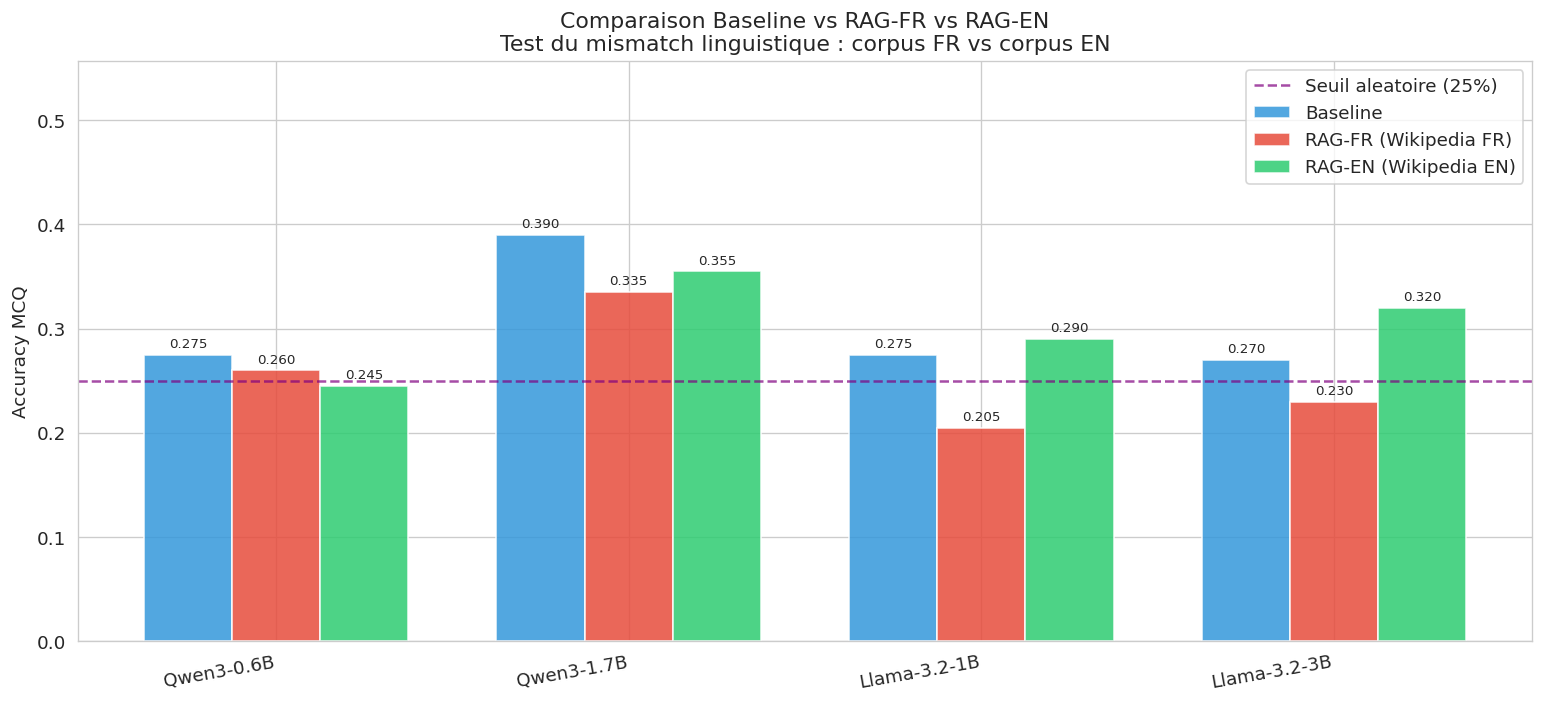

Figure 1 sauvegardee.


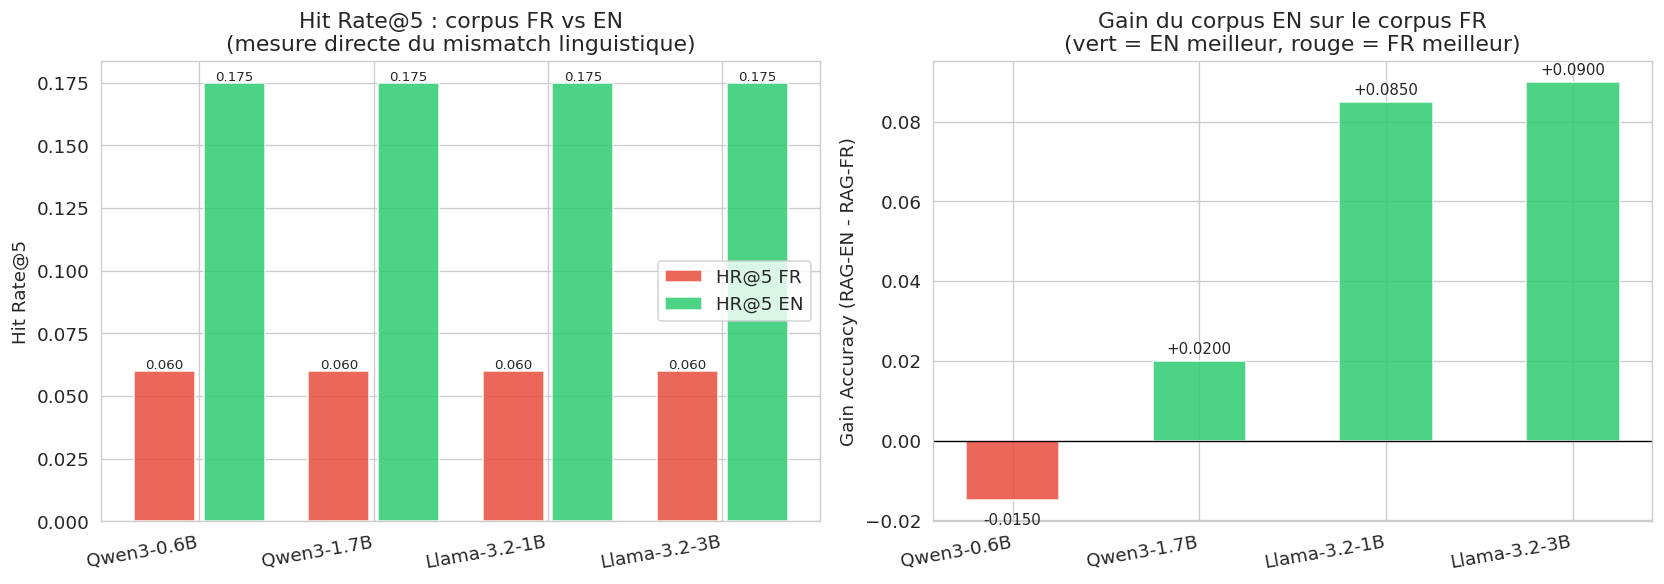

Figure 2 sauvegardee.


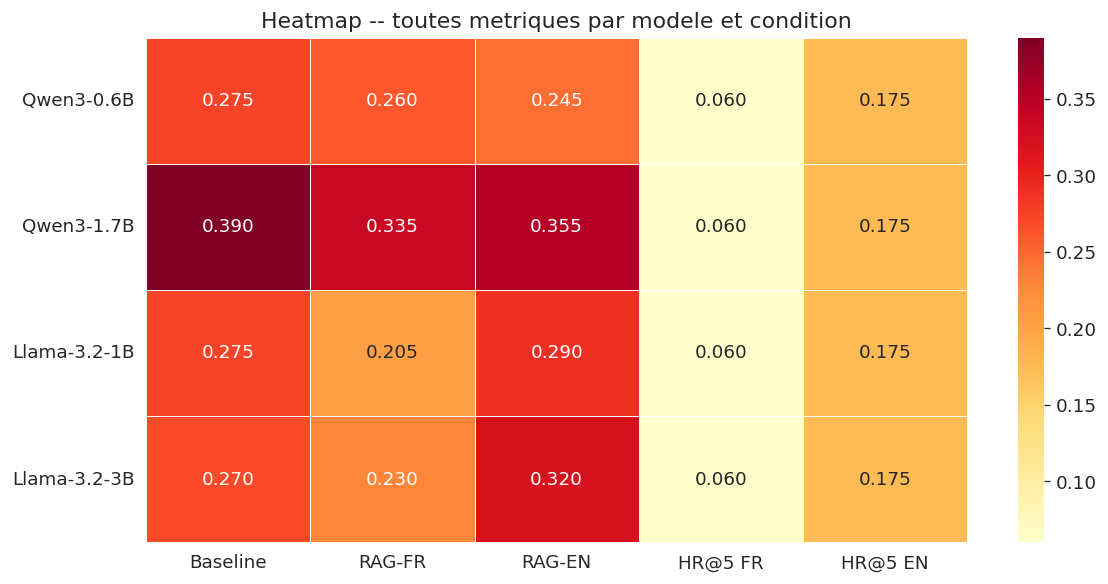

Figure 3 sauvegardee.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 11

model_names   = df_comparison['Modele'].tolist()
n_models      = len(model_names)
x             = np.arange(n_models)
width         = 0.25

base_accs  = df_comparison['Baseline Acc'].values.astype(float)
fr_accs    = df_comparison['RAG-FR Acc'].values.astype(float)
en_accs    = df_comparison['RAG-EN Acc'].values.astype(float)
hr_fr      = df_comparison['HR@5 FR'].values.astype(float)
hr_en      = df_comparison['HR@5 EN'].values.astype(float)
gain_en_fr = df_comparison['Gain EN-FR (abs)'].values.astype(float)

# ---- Figure 1 : Accuracy Baseline / RAG-FR / RAG-EN -------------------------
fig, ax = plt.subplots(figsize=(13, 6))
b1 = ax.bar(x - width, base_accs, width, label='Baseline',
            color='#3498db', alpha=0.85, edgecolor='white')
b2 = ax.bar(x,          fr_accs,  width, label='RAG-FR (Wikipedia FR)',
            color='#e74c3c', alpha=0.85, edgecolor='white')
b3 = ax.bar(x + width,  en_accs,  width, label='RAG-EN (Wikipedia EN)',
            color='#2ecc71', alpha=0.85, edgecolor='white')
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + 0.004,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)
ax.axhline(y=0.25, color='purple', linestyle='--', linewidth=1.5,
           label='Seuil aleatoire (25%)', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=10, ha='right')
ax.set_ylabel('Accuracy MCQ')
ax.set_ylim(0, max(en_accs.max(), base_accs.max()) * 1.3 + 0.05)
ax.set_title('Comparaison Baseline vs RAG-FR vs RAG-EN\n'
             'Test du mismatch linguistique : corpus FR vs corpus EN')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig1_baseline_ragfr_ragen.png', bbox_inches='tight')
plt.show()
print("Figure 1 sauvegardee.")

# ---- Figure 2 : HR@5 FR vs EN + Gain EN-FR ----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(x - 0.2, hr_fr, 0.35, label='HR@5 FR', color='#e74c3c', alpha=0.85)
axes[0].bar(x + 0.2, hr_en, 0.35, label='HR@5 EN', color='#2ecc71', alpha=0.85)
for i, (f, e) in enumerate(zip(hr_fr, hr_en)):
    axes[0].text(i-0.2, f+0.001, f'{f:.3f}', ha='center', fontsize=8)
    axes[0].text(i+0.2, e+0.001, f'{e:.3f}', ha='center', fontsize=8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=10, ha='right')
axes[0].set_ylabel('Hit Rate@5')
axes[0].set_title('Hit Rate@5 : corpus FR vs EN\n'
                  '(mesure directe du mismatch linguistique)')
axes[0].legend()

colors_g = ['#2ecc71' if g >= 0 else '#e74c3c' for g in gain_en_fr]
bars_g   = axes[1].bar(x, gain_en_fr, 0.5, color=colors_g, alpha=0.85, edgecolor='white')
for bar in bars_g:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.,
                 h + (0.001 if h >= 0 else -0.003),
                 f'{h:+.4f}', ha='center',
                 va='bottom' if h >= 0 else 'top', fontsize=9)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=10, ha='right')
axes[1].set_ylabel('Gain Accuracy (RAG-EN - RAG-FR)')
axes[1].set_title('Gain du corpus EN sur le corpus FR\n'
                  '(vert = EN meilleur, rouge = FR meilleur)')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig2_mismatch_analysis.png', bbox_inches='tight')
plt.show()
print("Figure 2 sauvegardee.")

# ---- Figure 3 : Heatmap complete --------------------------------------------
metrics_df = pd.DataFrame({
    'Baseline': base_accs,
    'RAG-FR':   fr_accs,
    'RAG-EN':   en_accs,
    'HR@5 FR':  hr_fr,
    'HR@5 EN':  hr_en,
}, index=model_names)
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(metrics_df, annot=True, fmt='.3f', cmap='YlOrRd',
            linewidths=0.5, ax=ax)
ax.set_title('Heatmap -- toutes metriques par modele et condition')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig3_heatmap_metrics.png', bbox_inches='tight')
plt.show()
print("Figure 3 sauvegardee.")


## Etape 7 -- Analyse des facteurs

In [ ]:
# == Facteur 1 : Taille du modele =============================================
print("=" * 60)
print("ANALYSE -- Facteur : Taille du modele")
print("=" * 60)
for _, row in df_comparison.sort_values('Taille (B)').iterrows():
    print(f"  {row['Modele']:20s} ({row['Taille (B)']:.1f}B) : "
          f"Baseline Acc={row['Baseline Acc']:.4f}, "
          f"RAG Acc={row['RAG Acc']:.4f}")

# Correlation taille vs accuracy
if len(df_comparison) >= 3:
    from scipy import stats
    corr, p_val = stats.pearsonr(df_comparison['Taille (B)'], df_comparison['RAG Acc'])
    print(f"\n  Correlation (Pearson) Taille vs RAG Acc : r={corr:.4f}, p={p_val:.4f}")
    if p_val < 0.05:
        print(f"  --> Correlation significative (p < 0.05)")
    else:
        print(f"  --> Correlation non significative (p >= 0.05)")

# == Facteur 2 : Famille de modele ============================================
print(f"\n{'='*60}")
print("ANALYSE -- Facteur : Famille de modele")
print("=" * 60)
family_means = df_comparison.groupby('Famille').agg({
    'RAG Acc': 'mean',
    'RAG F1': 'mean',
    'Baseline Acc': 'mean',
    'Delta Acc': 'mean',
    'Taille (B)': 'mean'
}).round(4)
print(family_means.to_string())

print(f"\n  Meilleure famille (RAG Acc moyenne) : {family_means['RAG Acc'].idxmax()} "
      f"({family_means['RAG Acc'].max():.4f})")

# == Facteur 3 : Impact du RAG par modele =====================================
print(f"\n{'='*60}")
print("ANALYSE -- Facteur : Impact du RAG")
print("=" * 60)
for _, row in df_comparison.iterrows():
    delta = row['Delta Acc']
    if delta > 0.02:
        impact = "POSITIF"
    elif delta < -0.02:
        impact = "NEGATIF"
    else:
        impact = "NEUTRE"
    print(f"  {row['Modele']:20s} : delta={row['Delta Acc']:+.4f} ({impact})")

avg_delta = df_comparison['Delta Acc'].mean()
print(f"\n  Impact moyen du RAG sur l'Accuracy : {avg_delta:+.4f}")
n_positive = (df_comparison['Delta Acc'] > 0).sum()
print(f"  Modeles ameliores par le RAG : {n_positive}/{len(df_comparison)}")

# == Facteur 4 : Latence ======================================================
print(f"\n{'='*60}")
print("ANALYSE -- Facteur : Latence (temps/question)")
print("=" * 60)
for _, row in df_comparison.iterrows():
    time_baseline = row['Temps Baseline (s)'] / MAX_QUESTIONS
    time_rag = row['Temps RAG (s)'] / MAX_QUESTIONS
    overhead = time_rag - time_baseline
    print(f"  {row['Modele']:20s} : "
          f"Baseline={time_baseline:.2f}s/q, "
          f"RAG={time_rag:.2f}s/q, "
          f"Overhead={overhead:+.2f}s/q")

# == Facteur 5 : Efficacite (Accuracy / Taille) ===============================
print(f"\n{'='*60}")
print("ANALYSE -- Facteur : Efficacite (RAG Acc / Taille)")
print("=" * 60)
df_comparison['Efficacite'] = df_comparison['RAG Acc'] / df_comparison['Taille (B)']
for _, row in df_comparison.sort_values('Efficacite', ascending=False).iterrows():
    print(f"  {row['Modele']:20s} : Efficacite={row['Efficacite']:.4f} "
          f"(Acc={row['RAG Acc']:.4f} / {row['Taille (B)']:.1f}B)")

ANALYSE -- Facteur : Taille du modele
  Qwen3-0.6B           (0.6B) : Baseline Acc=0.2750, RAG Acc=0.2600
  Llama-3.2-1B         (1.0B) : Baseline Acc=0.2750, RAG Acc=0.2050
  Qwen3-1.7B           (1.7B) : Baseline Acc=0.3900, RAG Acc=0.3350
  Llama-3.2-3B         (3.0B) : Baseline Acc=0.2700, RAG Acc=0.2300

  Correlation (Pearson) Taille vs RAG Acc : r=-0.0098, p=0.9902
  --> Correlation non significative (p >= 0.05)

ANALYSE -- Facteur : Famille de modele
         RAG Acc  RAG F1  Baseline Acc  Delta Acc  Taille (B)
Famille                                                      
Llama     0.2175  0.0036        0.2725     -0.055        2.00
Qwen      0.2975  0.0063        0.3325     -0.035        1.15

  Meilleure famille (RAG Acc moyenne) : Qwen (0.2975)

ANALYSE -- Facteur : Impact du RAG
  Qwen3-0.6B           : delta=-0.0150 (NEUTRE)
  Qwen3-1.7B           : delta=-0.0550 (NEGATIF)
  Llama-3.2-1B         : delta=-0.0700 (NEGATIF)
  Llama-3.2-3B         : delta=-0.0400 (NEGATIF)

  

## Etape 8 -- Analyse qualitative

Examen des cas ou les modeles divergent dans leurs predictions,
pour comprendre les forces et faiblesses de chaque LLM.

In [ ]:
# == Analyse des desaccords entre modeles ======================================
print("=" * 60)
print("ANALYSE QUALITATIVE -- Desaccords entre modeles")
print("=" * 60)

# Collecter les predictions RAG de chaque modele
model_predictions = {}
for name, res in all_results.items():
    if 'error' in res:
        continue
    model_predictions[name] = res['predictions']['rag_letters']

valid_models = list(model_predictions.keys())

if len(valid_models) >= 2:
    # Trouver les questions ou les modeles ne sont pas d'accord
    disagreements = []
    for i in range(MAX_QUESTIONS):
        preds_i = {m: model_predictions[m][i] for m in valid_models}
        unique_preds = set(preds_i.values())
        if len(unique_preds) > 1:
            correct = correct_letters[i]
            n_correct = sum(1 for p in preds_i.values() if p.upper() == correct.upper())
            disagreements.append({
                'index': i,
                'question': questions[i][:200],
                'correct': correct,
                'predictions': preds_i,
                'n_correct': n_correct,
            })

    print(f"\n  Nombre de desaccords : {len(disagreements)} / {MAX_QUESTIONS} "
          f"({len(disagreements)/MAX_QUESTIONS*100:.1f}%)")
    print(f"  Nombre d'accords unanimes : {MAX_QUESTIONS - len(disagreements)}")

    # Montrer les 10 premiers desaccords
    print(f"\n  --- Exemples de desaccords ---")
    for j, d in enumerate(disagreements[:10]):
        print(f"\n  Question {d['index']} : {d['question']}")
        print(f"    Reponse correcte : {d['correct']}")
        for m, p in d['predictions'].items():
            status = "OK" if p.upper() == d['correct'].upper() else "FAUX"
            print(f"    {m:20s} : {p} ({status})")

    # Matrice d'accord entre modeles
    print(f"\n  --- Matrice d'accord (proportion) ---")
    if len(valid_models) >= 2:
        agreement_matrix = {}
        for m1 in valid_models:
            agreement_matrix[m1] = {}
            for m2 in valid_models:
                agreement = sum(
                    1 for i in range(MAX_QUESTIONS)
                    if model_predictions[m1][i].upper() == model_predictions[m2][i].upper()
                ) / MAX_QUESTIONS
                agreement_matrix[m1][m2] = agreement

        df_agreement = pd.DataFrame(agreement_matrix)
        print(df_agreement.round(3).to_string())

    # Vote majoritaire
    print(f"\n  --- Vote majoritaire ---")
    majority_correct = 0
    for i in range(MAX_QUESTIONS):
        preds_i = [model_predictions[m][i].upper() for m in valid_models]
        vote_counts = Counter(preds_i)
        majority_vote = vote_counts.most_common(1)[0][0]
        if majority_vote == correct_letters[i].upper():
            majority_correct += 1
    majority_acc = majority_correct / MAX_QUESTIONS
    print(f"  Accuracy du vote majoritaire : {majority_acc:.4f}")
    print(f"  (compare au meilleur modele individuel : {df_comparison['RAG Acc'].max():.4f})")

else:
    print("  Pas assez de modeles valides pour l'analyse qualitative.")

ANALYSE QUALITATIVE -- Desaccords entre modeles

  Nombre de desaccords : 182 / 200 (91.0%)
  Nombre d'accords unanimes : 18

  --- Exemples de desaccords ---

  Question 0 : While the Tiangong-1 and Shenzhou-9 combination is in orbit, the celestial system it forms with the celestial body it orbits is of the same level as which of the following? (　　)
    Reponse correcte : D
    Qwen3-0.6B           : D (OK)
    Qwen3-1.7B           : C (FAUX)
    Llama-3.2-1B         : A (FAUX)
    Llama-3.2-3B         : C (FAUX)

  Question 1 : When Tiangong-1 and Shenzhou-9 successfully docked, which city had the longest daylight hours? (　　)
    Reponse correcte : A
    Qwen3-0.6B           : A (OK)
    Qwen3-1.7B           : A (OK)
    Llama-3.2-1B         : A (OK)
    Llama-3.2-3B         : B (FAUX)

  Question 2 : Which of the following statements about the Tiangong-1 and Shenzhou-9 combination during its in-orbit operation is incorrect? (　　)
    Reponse correcte : B
    Qwen3-0.6B           : A 

## Etape 9 -- Sauvegarde

In [ ]:
import json

# == Sauvegarde JSON -- Tous les resultats =====================================
# Creer une version serialisable (sans les listes de predictions)
results_json = {}
for name, res in all_results.items():
    if 'error' in res:
        results_json[name] = res
        continue
    results_json[name] = {
        'model_id': res['model_id'],
        'family': res['family'],
        'size_B': res['size_B'],
        'baseline': res['baseline'],
        'rag': res['rag'],
        'retrieval': res['retrieval'],
        'improvement': res['improvement'],
    }

# Ajouter les metadonnees
output_json = {
    'phase': '2a',
    'description': 'Comparaison Multi-LLMs sur GeoSQA avec RAG',
    'config': CONFIG,
    'n_questions': MAX_QUESTIONS,
    'n_models': len(MODELS),
    'results': results_json,
}

json_path = f'{RESULTS_DIR}/phase2a_all_results.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(output_json, f, indent=2, ensure_ascii=False)
print(f"Resultats JSON sauvegardes : {json_path}")

# == Sauvegarde CSV -- Tableau comparatif ======================================
csv_path = f'{RESULTS_DIR}/phase2a_comparison.csv'
df_comparison.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"Tableau comparatif CSV sauvegarde : {csv_path}")

# == Sauvegarde CSV -- Predictions detaillees ==================================
pred_rows = []
for i in range(MAX_QUESTIONS):
    row = {
        'index': i,
        'question': questions[i][:500],
        'correct_letter': correct_letters[i],
        'correct_text': correct_texts[i][:200],
    }
    for name, res in all_results.items():
        if 'error' in res:
            continue
        row[f'{name}_baseline'] = res['predictions']['baseline_letters'][i]
        row[f'{name}_rag'] = res['predictions']['rag_letters'][i]
        row[f'{name}_baseline_ok'] = 1 if res['predictions']['baseline_letters'][i].upper() == correct_letters[i].upper() else 0
        row[f'{name}_rag_ok'] = 1 if res['predictions']['rag_letters'][i].upper() == correct_letters[i].upper() else 0
    pred_rows.append(row)

df_predictions = pd.DataFrame(pred_rows)
pred_csv_path = f'{RESULTS_DIR}/phase2a_predictions.csv'
df_predictions.to_csv(pred_csv_path, index=False, encoding='utf-8-sig')
print(f"Predictions detaillees CSV sauvegardees : {pred_csv_path}")

# == Affichage resume ==========================================================
print(f"\n{'='*60}")
print(f"FICHIERS GENERES")
print(f"{'='*60}")
print(f"  {json_path}")
print(f"  {csv_path}")
print(f"  {pred_csv_path}")
print(f"  {RESULTS_DIR}/fig1_accuracy_baseline_vs_rag.png")
print(f"  {RESULTS_DIR}/fig2_size_vs_accuracy.png")
print(f"  {RESULTS_DIR}/fig3_heatmap_metrics.png")
print(f"  {RESULTS_DIR}/fig4_improvement_delta.png")

# == Sauvegarde optionnelle sur Google Drive ===================================
SAVE_TO_DRIVE = True

if SAVE_TO_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive')

        import shutil
        drive_dest = '/content/drive/MyDrive/GeoR2LLMs/Phase2a/results'
        os.makedirs(drive_dest, exist_ok=True)

        for fname in os.listdir(RESULTS_DIR):
            src = os.path.join(RESULTS_DIR, fname)
            dst = os.path.join(drive_dest, fname)
            shutil.copy2(src, dst)
            print(f"Copie : {dst}")

        print(f"\nTous les resultats ont ete copies sur Google Drive : {drive_dest}")

    except ImportError:
        print("\nGoogle Drive non disponible (environnement non-Colab).")
    except Exception as e:
        print(f"\nErreur lors de la sauvegarde sur Google Drive : {e}")

Resultats JSON sauvegardes : results/phase2a_all_results.json
Tableau comparatif CSV sauvegarde : results/phase2a_comparison.csv
Predictions detaillees CSV sauvegardees : results/phase2a_predictions.csv

FICHIERS GENERES
  results/phase2a_all_results.json
  results/phase2a_comparison.csv
  results/phase2a_predictions.csv
  results/fig1_accuracy_baseline_vs_rag.png
  results/fig2_size_vs_accuracy.png
  results/fig3_heatmap_metrics.png
  results/fig4_improvement_delta.png

Erreur lors de la sauvegarde sur Google Drive : mount failed


## Résumé Phase 2a — GeoSQA

### Configuration
- Dataset : GeoSQA (200 questions, ZH→EN, traduction du chinois)
- Corpus testé : Wikipedia FR (300 articles) + Wikipedia EN (300 articles)
- Retriever : BAAI/bge-m3 + FAISS (IndexFlatIP)
- GPU : Tesla T4 (15.6 Go)

### Métriques de retrieval (indépendantes du LLM)
| Corpus | HR@5 | MRR@5 | Facteur vs FR |
|--------|------|-------|---------------|
| Wikipedia FR | 0.0600 | 0.0367 | ×1.0 (référence) |
| Wikipedia EN | **0.1750** | **0.1007** | **×2.9** |

→ **Mismatch linguistique CONFIRMÉ** : le corpus EN améliore le HR@5 d'un facteur ×2.9.
BGE-m3 encode correctement — c'était le corpus FR qui limitait le retrieval.

### Classement des modèles

| Rang | Modèle | Baseline | RAG-FR | Δrel FR | RAG-EN | Δrel EN |
|------|--------|----------|--------|---------|--------|---------|
| 1 | Qwen3-1.7B | **0.3900** | 0.3350 | -14.1% | 0.3550 | -9.0% |
| 2 | Llama-3.2-3B | 0.2700 | 0.2300 | -14.8% | **0.3200** | +18.5% |
| 3 | Qwen3-0.6B | 0.2750 | 0.2600 | -5.5% | 0.2450 | -10.9% |
| 4 | Llama-3.2-1B | 0.2750 | 0.2050 | -25.5% | 0.2900 | +5.5% |
| 5 | Ministral-3B | ERREUR | ERREUR | — | ERREUR | — |

### Gain moyen EN vs FR (accuracy)
| Modèle | RAG-FR | RAG-EN | Gain EN−FR (abs) | Gain EN−FR (rel%) |
|--------|--------|--------|------------------|-------------------|
| Qwen3-1.7B | 0.3350 | 0.3550 | +0.0200 | +6.0% |
| Llama-3.2-3B | 0.2300 | 0.3200 | +0.0900 | +39.1% |
| Qwen3-0.6B | 0.2600 | 0.2450 | -0.0150 | -5.8% |
| Llama-3.2-1B | 0.2050 | 0.2900 | +0.0850 | +41.5% |
| **Moyenne** | **0.2575** | **0.3025** | **+0.0450** | **+20.2%** |

### Analyse des facteurs

**Facteur 1 — Famille du modèle**
- Qwen (RAG-FR moy.) : 0.2975 > Llama (RAG-FR moy.) : 0.2175
- La famille conditionne davantage les performances que la taille seule

**Facteur 2 — Taille du modèle (intra-famille)**
- Qwen : 0.6B→1.7B : +28.8% (RAG-FR), +44.9% (RAG-EN) → taille aide
- Llama : 1B→3B : +12.2% (RAG-FR), +10.3% (RAG-EN) → taille aide
- Corrélation globale Pearson : r = -0.010, p = 0.990 (non significatif, n=4)

**Facteur 3 — Impact du RAG**
- RAG-FR : impact moyen = -15.0% (négatif pour tous les modèles)
- RAG-EN : impact moyen = +1.0% (quasi-nul, mais positif pour 2/4 modèles)
- 0/4 modèles améliorés par RAG-FR ; 2/4 améliorés par RAG-EN (Llama-3.2-3B, Llama-3.2-1B)

**Facteur 4 — Latence (overhead RAG)**
| Modèle | Baseline (s/q) | RAG-FR (s/q) | Overhead |
|--------|----------------|--------------|----------|
| Qwen3-0.6B | 0.60 | 1.00 | +0.40 |
| Qwen3-1.7B | 0.49 | 1.43 | +0.94 |
| Llama-3.2-1B | 0.68 | 1.53 | +0.85 |
| Llama-3.2-3B | 1.35 | 2.89 | +1.53 |

**Facteur 5 — Efficacité (RAG-FR Acc / Taille)**
- Qwen3-0.6B : 0.4333 (meilleure efficacité)
- Llama-3.2-1B : 0.2050
- Qwen3-1.7B : 0.1971
- Llama-3.2-3B : 0.0767

### Analyse qualitative
- Taux de désaccord inter-modèles : **91.0%** (182/200 questions)
- Accords unanimes : 18/200
- Vote majoritaire : **0.2700** < meilleur individuel (0.3350 Qwen3-1.7B)
- Matrice d'accord : 26.5% à 41.0% entre paires de modèles

### Conclusions

1. **Mismatch linguistique confirmé** : HR@5 passe de 0.060 (FR) à 0.175 (EN), facteur ×2.9. BGE-m3 n'est pas en cause — le corpus FR était inadapté aux questions EN.

2. **RAG-FR nuit à tous les modèles** : Δrel moyen = -15.0%. Le mismatch annule et inverse l'apport du RAG.

3. **RAG-EN améliore partiellement** : Llama-3.2-3B (+18.5%) et Llama-3.2-1B (+5.5%) bénéficient du corpus EN. Qwen3-1.7B reste en dessous de sa baseline même avec EN (-9.0%) — ses connaissances internes suffisent.

4. **Qwen3-1.7B domine en Baseline et RAG-FR** : Accuracy baseline = 0.3900, la meilleure. Le classement s'inverse partiellement en RAG-EN où Llama-3.2-3B monte à 0.3200.

5. **Pas de corrélation taille-performance** : r = -0.010, p = 0.990. La famille du modèle est le facteur déterminant, pas la taille.

6. **Vote majoritaire sous-performant** : 0.2700 < Qwen3-1.7B (0.3350). Les erreurs se concentrent sur les mêmes questions difficiles.

7. **Ministral-3B incompatible** : Mistral3Config non supportée par AutoModelForCausalLM. Résultats non disponibles.

### Prochaines étapes
- **Phase 2b** : Évaluation sur GKMC (même protocole FR+EN)
- **Phase 2c** : Évaluation sur Tourism-QA (corpus EN natif)
- **Phase 2d** : Analyse factorielle croisée (modèles × datasets × corpus)